# Simulating the Cottrell Case with `solve_ivp`

In chronoamperometry, a potential step is applied to a working electrode under diffusion control, driving instantaneous consumption of the electroactive species at the surface:

$$c(0, t) = 0 \quad \text{for } t > 0$$

For a planar macroelectrode under semi-infinite linear diffusion, the resulting current transient is described by the celebrated **Cottrell equation**:

$$I(t) = \frac{n F A \sqrt{D} c^*}{\sqrt{\pi t}}$$

where:
- $n$: stoichiometric number of electrons transferred
- $F$: Faraday constant ($96485.3\text{ C/mol}$)
- $A$: electrode surface area ($\text{cm}^2$)
- $D$: diffusion coefficient ($\text{cm}^2/\text{s}$)
- $c^*$: bulk concentration ($\text{mol/cm}^3$)
- $t$: elapsed time ($\text{s}$)

In this tutorial, you will learn how to:
1. Define a 1D Cottrell diffusion problem using Soft Potato's `DiffusionProblem`.
2. Simulate the concentration profiles and surface flux using the adaptive `solve_ivp` solver.
3. Calculate the electrochemical current and validate it directly against the analytical Cottrell equation.


## 1. Parameters and Spatial Grid Sizing

We consider the oxidation of a reduced species $\text{Red} \to \text{Ox} + n e^-$ ($n = 1$) at a planar electrode with area $A = 0.07\text{ cm}^2$.
- Diffusion coefficient: $D = 10^{-5}\text{ cm}^2/\text{s}$
- Bulk concentration: $c^* = 1.0\text{ mM} = 10^{-6}\text{ mol/cm}^3$
- Step duration: $t_{\text{end}} = 2.0\text{ s}$

The characteristic diffusion penetration depth scales as $\delta \approx 6\sqrt{D t_{\text{end}}} \approx 270\,\mu\text{m}$. To ensure the semi-infinite boundary condition holds throughout the simulation, the domain length $L = 500\,\mu\text{m} = 0.05\text{ cm}$ is sized safely beyond $\delta$.


In [1]:
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np

from softpotato.solver import DiffusionProblem, DirichletBC, get_solver

# Physical constants and electrochemical parameters
F = 96485.3  # Faraday constant (C/mol)
n = 1  # Number of electrons transferred
A = 0.07  # Electrode geometric area (cm²)
D = 1e-5  # Diffusion coefficient (cm²/s)
c_bulk = 1e-6  # Bulk concentration (mol/cm³, equivalent to 1.0 mM)
t_end = 2.0  # Duration of the potential step (s)

# Spatial grid: domain L sized safely beyond diffusion layer (6*sqrt(D*t_end) ≈ 270 µm)
L = 0.05  # Domain length (cm, 500 µm)
x = np.linspace(0.0, L, 201)  # 201 points -> dx = 2.5 µm

## 2. Formulating the Problem & Solving with `solve_ivp`

We set up the initial and boundary conditions:
- **Initial condition**: uniform bulk concentration $c(x, 0) = c^*$.
- **Electrode surface** ($x = 0$): Dirichlet boundary condition $c(0, t) = 0$ (instantaneous consumption).
- **Bulk boundary** ($x = L$): Dirichlet boundary condition $c(L, t) = c^*$.

We solve this initial-boundary value problem using `get_solver("solve_ivp")`. This Method of Lines (MOL) solver discretizes the spatial diffusion operator into a coupled system of ODEs and integrates in time with SciPy's adaptive 5th-order stiff `Radau` algorithm, eliminating manual $\Delta t$ tuning and stability constraints.


In [2]:
# 1. Define the 1D Cottrell diffusion problem
problem = DiffusionProblem(
    grid=x,
    diffusivity={"Red": D},
    boundary_conditions={"Red": (DirichletBC(0.0), DirichletBC(c_bulk))},
    initial_conditions={"Red": c_bulk},
)

# 2. Integrate with solve_ivp (Method of Lines with adaptive Radau)
t_eval = np.linspace(0.0, t_end, 51)
solver = get_solver("solve_ivp")
result = solver.solve(problem, t_span=(0.0, t_end), t_eval=t_eval)

print(f"Solver status: {result.message}")
print(f"Concentration grid shape: {result['Red'].shape} (time steps × spatial points)")

Solver status: SciPy solve_ivp completed successfully.
Concentration grid shape: (51, 201) (time steps × spatial points)


## 3. Visualizing Concentration Profiles

The concentration profile $c(x, t)$ shows how the depletion layer expands into the bulk solution over time as species $\text{Red}$ is consumed at the electrode surface ($x = 0$).


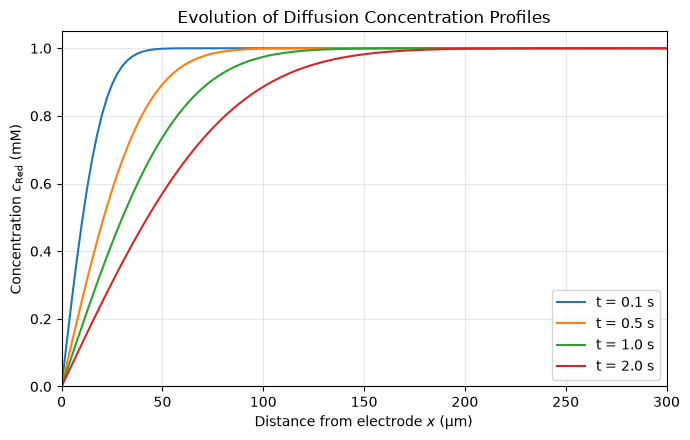

In [3]:
# Select representative times for visualization
selected_times = [0.1, 0.5, 1.0, 2.0]

plt.figure(figsize=(7, 4.5))
for t_val in selected_times:
    idx = np.argmin(np.abs(result.t - t_val))
    plt.plot(result.x * 1e4, result["Red"][idx] * 1e6, label=f"t = {t_val:.1f} s")

plt.xlabel("Distance from electrode $x$ (µm)")
plt.ylabel(r"Concentration $c_{\mathrm{Red}}$ (mM)")
plt.title("Evolution of Diffusion Concentration Profiles")
plt.xlim(0, 300)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Extracting Current & Comparing with the Cottrell Equation

By Faraday's law, the electrical current $I(t)$ is directly proportional to the molar flux at the electrode surface ($x = 0$):

$$I(t) = -n F A J_{\mathrm{surface}}(t) = n F A D \left.\frac{\partial c_{\mathrm{Red}}}{\partial x}\right|_{x=0}$$

Soft Potato automatically calculates this boundary flux using a 2nd-order finite difference stencil and stores it in `result.fluxes["Red"]`.

We now compare the simulated current against the analytical Cottrell current:

$$I_{\text{analytical}}(t) = \frac{n F A \sqrt{D} c^*}{\sqrt{\pi t}}$$


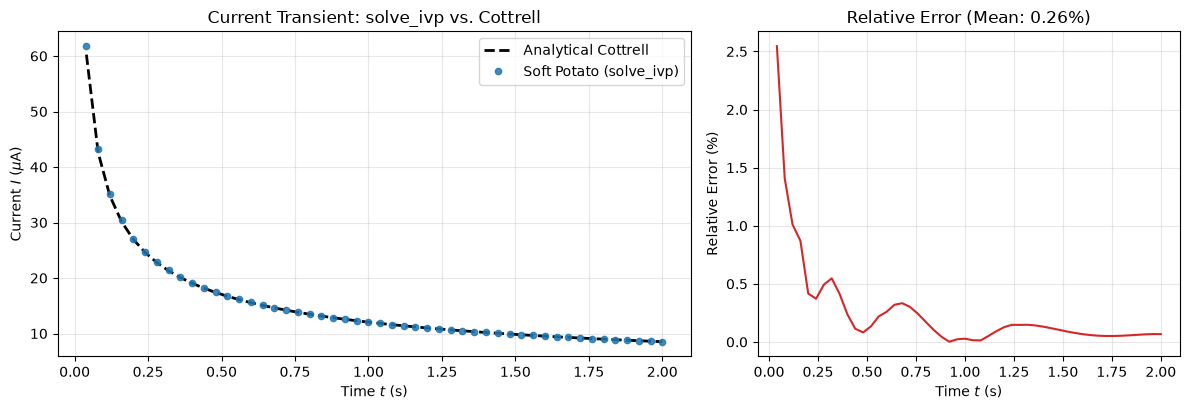

Mean relative error: 0.255%
Relative error at t = 2.0 s: 0.067%


In [4]:
# 1. Numerical current in microamperes (uA): I = -n * F * A * J
I_numerical = -n * F * A * result.fluxes["Red"] * 1e6

# 2. Analytical Cottrell current for t > 0
t_eval_nz = result.t[1:]
I_cottrell = (n * F * A * np.sqrt(D) * c_bulk / np.sqrt(np.pi * t_eval_nz)) * 1e6

# 3. Plot comparison: Current transient and relative error
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.8, 1.2]}
)

# Left panel: Current transient
ax1.plot(
    t_eval_nz,
    I_cottrell,
    "k--",
    linewidth=2,
    label="Analytical Cottrell",
    zorder=2,
)
ax1.plot(
    t_eval_nz,
    I_numerical[1:],
    "o",
    color="tab:blue",
    markersize=4.5,
    label="Soft Potato (solve_ivp)",
    alpha=0.85,
    zorder=3,
)
ax1.set_xlabel("Time $t$ (s)")
ax1.set_ylabel(r"Current $I$ ($\mu\mathrm{A}$)")
ax1.set_title("Current Transient: solve_ivp vs. Cottrell")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Right panel: Relative error (%)
rel_error = np.abs(I_numerical[1:] - I_cottrell) / I_cottrell * 100
ax2.plot(t_eval_nz, rel_error, color="tab:red", linewidth=1.5)
ax2.set_xlabel("Time $t$ (s)")
ax2.set_ylabel("Relative Error (%)")
ax2.set_title(f"Relative Error (Mean: {np.mean(rel_error):.2f}%)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean relative error: {np.mean(rel_error):.3f}%")
print(f"Relative error at t = 2.0 s: {rel_error[-1]:.3f}%")

## 5. Summary & Key Takeaways

Simulating Cottrell chronoamperometry in Soft Potato requires just three straightforward steps:
1. **Formulate the physics**: Define the grid, species diffusivity, boundary conditions (`DirichletBC(0.0)` at the surface and `DirichletBC(c_bulk)` in the bulk), and uniform initial condition with `DiffusionProblem`.
2. **Solve with** `solve_ivp`: Call `get_solver("solve_ivp").solve(...)`. The adaptive stiff Radau integrator resolves the sharp initial concentration gradient automatically without needing manual time step selection or stability constraints.
3. **Analyze results**: Access full spatio-temporal profiles with `result["Red"]` and surface fluxes directly with `result.fluxes["Red"]` to obtain the electrical current. As shown above, the numerical current matches the Cottrell analytical solution with < 0.3\% average error across the transient.
